In [1]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.image import imread
from cv2 import randu, add
from skimage.metrics import structural_similarity as ssim

synt_path = '../../synt_one_channel'
val_path = '/mnt/jet1/zagorulia/val_one_channel'

In [2]:
print(os.listdir(f'{val_path}'))
print(os.listdir(f'{synt_path}'))

['3', '1', '2', '0']
['3', '0', '2', '1']


In [3]:
def getIntensities(morph_cls):
    synt_intensities = []
    val_intensities = []
    for file in os.listdir(f'{synt_path}/{morph_cls}'):
        im = imread(f'{synt_path}/{morph_cls}/{file}')
        im = im.clip(min=0)
        im = (im / im.max() * 255)
        # print(im.min(), im.max(), im.dtype)
        noise = np.zeros(im.shape, dtype=im.dtype)
        randu(noise, -25, 0)
        im = add(im, noise)
        im = im.clip(min=0)
        im /= im.max()
        synt_intensities.append(im.sum())

    for file in os.listdir(f'{val_path}/{morph_cls}'):
        im = imread(f'{val_path}/{morph_cls}/{file}')
        # print(im.min(), im.max())
        val_intensities.append(im.sum())
    return (synt_intensities, val_intensities)

In [ ]:
def plotIntensities(synt_intensities, val_intensities):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].hist(np.array(synt_intensities).ravel(), bins=100, density=)
    axes[0].axvline(np.array(synt_intensities).mean(), ls='--', color='black', label='mean')
    axes[0].axvline(np.median(np.array(synt_intensities)), ls='--', color='red', label='median')
    axes[0].set_title('Интегральная яркость (обучение)')
    axes[0].set_yscale('log')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].hist(np.array(val_intensities).ravel(), bins=100, density=True)
    axes[1].axvline(np.array(val_intensities).mean(), ls='--', color='black', label='mean')
    axes[1].axvline(np.median(np.array(val_intensities)), ls='--', color='red', label='median')
    axes[1].set_title('Интегральная яркость (валидация)')
    # axes[1].set_yscale('log')
    axes[1].grid(True)
    axes[1].legend()

## Single Point Source

652.0553 419.27856
8000 242


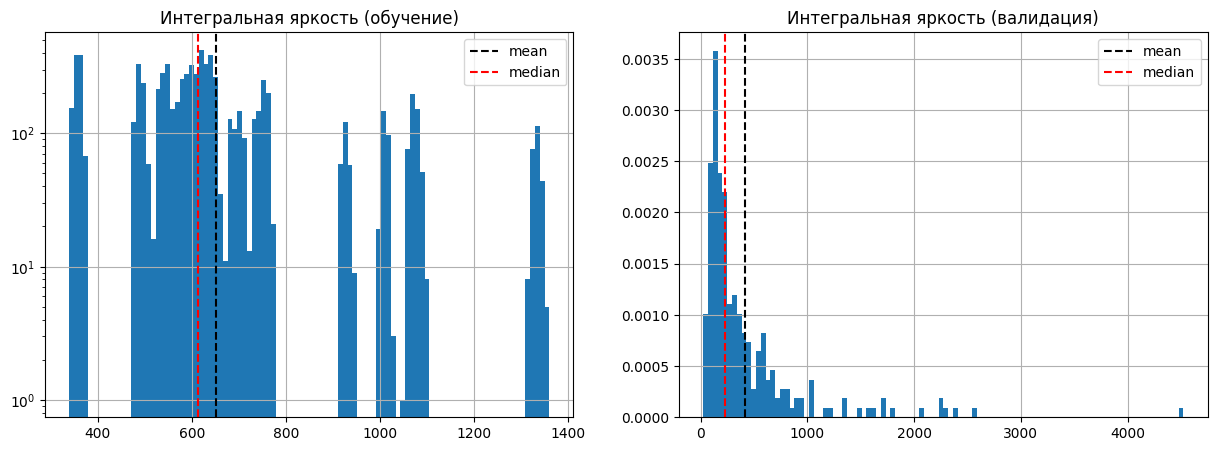

In [5]:
intensities = getIntensities(0)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)

## Double Point Source

931.3915 400.10684
8000 69


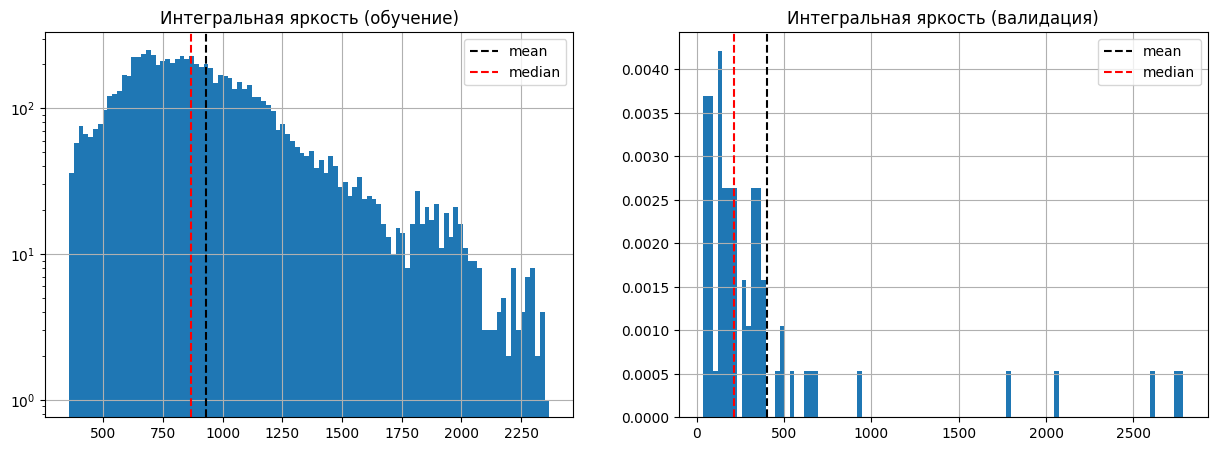

In [6]:
intensities = getIntensities(1)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)

## Single Jet Sources

690.59186 386.84912
8000 250


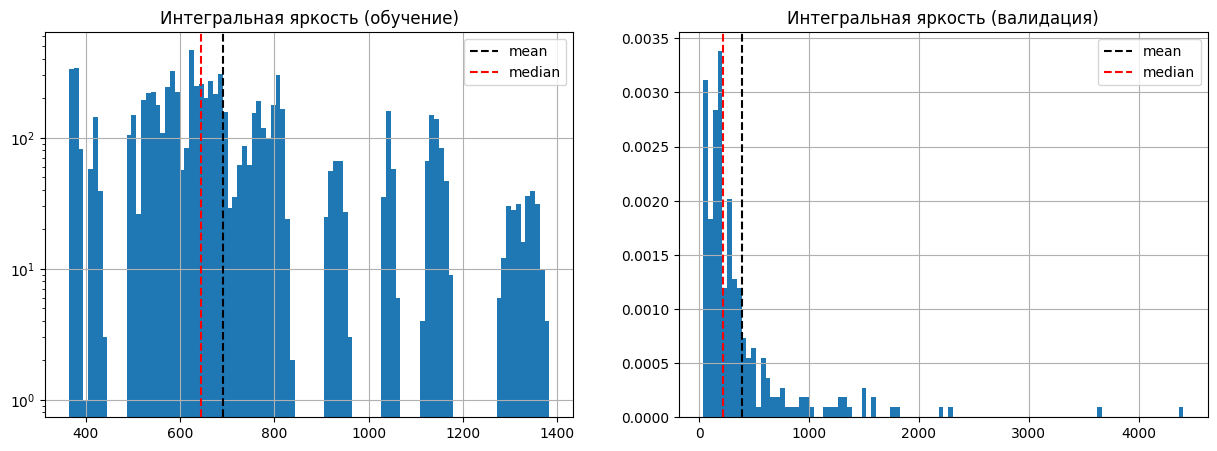

In [7]:
intensities = getIntensities(2)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)

## Double Jet Sources

722.5322 427.35464
8000 26


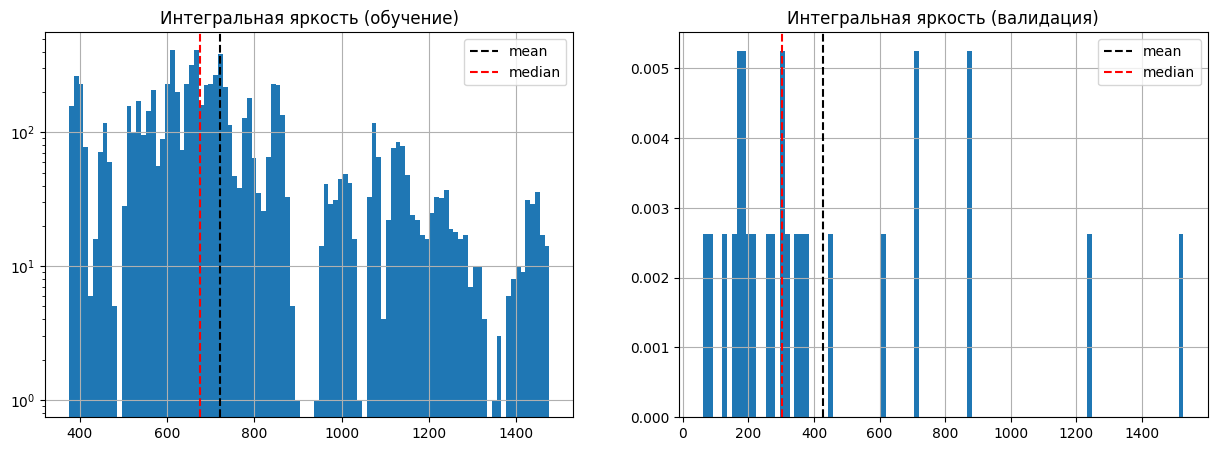

In [8]:
intensities = getIntensities(3)

print(np.array(intensities[0]).mean(), np.array(intensities[1]).mean())
print(len(intensities[0]), len(intensities[1]))

plotIntensities(*intensities)